In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
print("All imports successful!")

All imports successful!


# Loading the needed data

In [3]:
sales_path = "../DATA/RAW/sales_train_validation.csv"
calendar_path = "../DATA/RAW/calendar.csv"
prices_path = "../DATA/RAW/sell_prices.csv"

sales = pd.read_csv(sales_path)
calendar = pd.read_csv(calendar_path)
sell_prices = pd.read_csv(prices_path)

print("Sales:", sales.shape)
print("Calendar:", calendar.shape)
print("Prices:", sell_prices.shape)

Sales: (30490, 1919)
Calendar: (1969, 14)
Prices: (6841121, 4)


In [4]:
product_id = "FOODS_3_090"
store_id = "CA_3"

product_row = sales[
    (sales["item_id"] == product_id) &
    (sales["store_id"] == store_id)
].copy()

print("Selected series:", product_row.shape)
display(product_row.head())

Selected series: (1, 1919)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
8412,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,108,132,102,120,...,129,160,204,86,100,88,77,141,139,130


# Converting the Series into Long Format

In [ ]:
id_cols = [
    "id",
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

day_cols = [
    col for col in product_row.columns
    if col.startswith("d_")
]

series = product_row.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name="d",
    value_name="sales"
)
print("Series shape:", series.shape)
display(series.head())

Series shape: (1913, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_1,108
1,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_2,132
2,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_3,102
3,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_4,120
4,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_5,106


In [ ]:
calendar_features = calendar[
    [
        "d",
        "date",
        "wm_yr_wk",
        "wday",
        "month",
        "year",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2"
    ]
].copy()
calendar_features["date"] = pd.to_datetime(
    calendar_features["date"]
)
series = series.merge(
    calendar_features,
    on="d",
    how="left"
)
print(series.shape)
display(series.head())

(1913, 17)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2
0,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_1,108,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN
1,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_2,132,2011-01-30,11101,2,1,2011,NaN,NaN,NaN,NaN
2,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_3,102,2011-01-31,11101,3,1,2011,NaN,NaN,NaN,NaN
3,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_4,120,2011-02-01,11101,4,2,2011,NaN,NaN,NaN,NaN
4,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_5,106,2011-02-02,11101,5,2,2011,NaN,NaN,NaN,NaN


In [7]:
price_features = sell_prices[
    [
        "store_id",
        "item_id",
        "wm_yr_wk",
        "sell_price"
    ]
].copy()
series = series.merge(
    price_features,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)
print(series.shape)
display(series.head())

(1913, 18)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,sell_price
0,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_1,108,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,1.25
1,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_2,132,2011-01-30,11101,2,1,2011,NaN,NaN,NaN,NaN,1.25
2,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_3,102,2011-01-31,11101,3,1,2011,NaN,NaN,NaN,NaN,1.25
3,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_4,120,2011-02-01,11101,4,2,2011,NaN,NaN,NaN,NaN,1.25
4,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_5,106,2011-02-02,11101,5,2,2011,NaN,NaN,NaN,NaN,1.25


# Adding LightGBM Features

In [8]:
series = series.sort_values("date").reset_index(drop=True)
print(series[["date", "sales", "sell_price"]].head())

        date  sales  sell_price
0 2011-01-29    108        1.25
1 2011-01-30    132        1.25
2 2011-01-31    102        1.25
3 2011-02-01    120        1.25
4 2011-02-02    106        1.25


In [9]:
series["day_of_week"] = series["date"].dt.dayofweek
series["day_of_month"] = series["date"].dt.day
series["week_of_year"] = series["date"].dt.isocalendar().week.astype(int)
series["month"] = series["date"].dt.month
series["quarter"] = series["date"].dt.quarter
series["year"] = series["date"].dt.year

In [10]:
# The above couple of lines code tells that and learns things like Monday not equal to the Tuesday, 
# 1st day of the month not equal to 2nd day of the month, January not equal to February, etc. 
# These are all categorical features that can be used in the model.

In [11]:
#Now creating the Lag features

In [13]:
# Lag days means The leave which is on demand or planned or any time period between the deadline 
# and the current date. 

In [12]:
lag_days = [1, 7, 14, 28]

for lag in lag_days:
    series[f"lag_{lag}"] = series["sales"].shift(lag)

# Addinf the rolling demand features

In [15]:
series["rolling_mean_7"] = (
    series["sales"]
    .shift(1)
    .rolling(7)
    .mean()
)
series["rolling_mean_14"] = (
    series["sales"]
    .shift(1)
    .rolling(14)
    .mean()
)
series["rolling_mean_28"] = (
    series["sales"]
    .shift(1)
    .rolling(28)
    .mean()
)

In [16]:
series["price_change"] = (
    series["sell_price"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
)

# Check all the added resulting features

In [18]:
print("Shape:", series.shape)
display(
    series[
        [
            "date",
            "sales",
            "sell_price",
            "day_of_week",
            "month",
            "lag_1",
            "lag_7",
            "lag_14",
            "lag_28",
            "rolling_mean_7",
            "rolling_mean_14",
            "rolling_mean_28",
            "price_change"
        ]
    ].head(5)
)

Shape: (1913, 30)


,date,sales,sell_price,day_of_week,month,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,price_change
0,2011-01-29,108,1.25,5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-01-30,132,1.25,6,1,108.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2011-01-31,102,1.25,0,1,132.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,2011-02-01,120,1.25,1,2,102.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,2011-02-02,106,1.25,2,2,120.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [ ]:
# By the below code we are deleting the some of the rows which have NaN values in them. 
# This is because we have created lag features and rolling mean features which will have NaN values for the first few rows. 


# We will be deleting some rows(lag_28) as they are not useful for training the model. 

In [19]:
series_model = series.dropna().copy()

print("Original rows:", len(series))
print("Rows after feature engineering:", len(series_model))

Original rows: 1913
Rows after feature engineering: 4


In [20]:
series_model.isnull().sum()

id                 0
item_id            0
dept_id            0
cat_id             0
store_id           0
state_id           0
d                  0
sales              0
date               0
wm_yr_wk           0
wday               0
month              0
year               0
event_name_1       0
event_type_1       0
event_name_2       0
event_type_2       0
sell_price         0
day_of_week        0
day_of_month       0
week_of_year       0
quarter            0
lag_1              0
lag_7              0
lag_14             0
lag_28             0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_28    0
price_change       0
dtype: int64

In [21]:
series_model.shape

(4, 30)

In [22]:
series["is_event_1"] = series["event_name_1"].notna().astype(int)
series["is_event_2"] = series["event_name_2"].notna().astype(int)

In [23]:
required_columns = [
    "sales",
    "sell_price",
    "price_change",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28"
]

In [24]:
series_model = series.dropna(
    subset=required_columns
).copy()

print("Original rows:", len(series))
print("Model rows:", len(series_model))
print("Shape:", series_model.shape)

Original rows: 1913
Model rows: 1885
Shape: (1885, 32)


In [25]:
series_model[required_columns].isnull().sum()

sales              0
sell_price         0
price_change       0
lag_1              0
lag_7              0
lag_14             0
lag_28             0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_28    0
dtype: int64

# Time-Based Train/Test Split

In [26]:
forecast_horizon = 30

train_lgb = series_model.iloc[:-forecast_horizon].copy()
test_lgb = series_model.iloc[-forecast_horizon:].copy()

print("Training:", train_lgb.shape)
print("Testing :", test_lgb.shape)

print("\nTraining period:")
print(train_lgb["date"].min(), "to", train_lgb["date"].max())

print("\nTesting period:")
print(test_lgb["date"].min(), "to", test_lgb["date"].max())

Training: (1855, 32)
Testing : (30, 32)

Training period:
2011-02-26 00:00:00 to 2016-03-25 00:00:00

Testing period:
2016-03-26 00:00:00 to 2016-04-24 00:00:00


In [27]:
features = [
    "day_of_week",
    "day_of_month",
    "week_of_year",
    "month",
    "quarter",
    "year",
    "sell_price",
    "price_change",
    "is_event_1",
    "is_event_2",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28"
]
target = "sales"
X_train = train_lgb[features]
y_train = train_lgb[target]

X_test = test_lgb[features]
y_test = test_lgb[target]
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (1855, 17)
y_train: (1855,)
X_test : (30, 17)
y_test : (30,)


# Training the LightGBM

In [28]:
from lightgbm import LGBMRegressor
lgb_model = LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
lgb_model.fit(
    X_train,
    y_train
)
print("LightGBM training completed!")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1910
[LightGBM] [Info] Number of data points in the train set: 1855, number of used features: 15
[LightGBM] [Info] Start training from score 132.361725
LightGBM training completed!


# Now Prediction Part

In [29]:
lgb_predictions = lgb_model.predict(X_test)
print("Number of predictions:", len(lgb_predictions))
display(
    pd.DataFrame({
        "date": test_lgb["date"].values,
        "actual": y_test.values,
        "predicted": lgb_predictions
    }).head(10)
)

Number of predictions: 30


,date,actual,predicted
0,2016-03-26,218,191.569675
1,2016-03-27,212,119.366081
2,2016-03-28,61,119.685597
3,2016-03-29,62,86.073759
4,2016-03-30,71,93.531201
5,2016-03-31,130,87.271116
6,2016-04-01,156,167.569714
7,2016-04-02,133,194.232763
8,2016-04-03,114,146.365860
9,2016-04-04,80,101.568823


# Checking the model with Evaluation metrics

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
lgb_mae = mean_absolute_error(
    y_test,
    lgb_predictions
)
lgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lgb_predictions
    )
)
lgb_wmape = (
    np.sum(np.abs(y_test - lgb_predictions))
    / np.sum(np.abs(y_test))
) * 100
print(f"LightGBM MAE   : {lgb_mae:.2f}")
print(f"LightGBM RMSE  : {lgb_rmse:.2f}")
print(f"LightGBM WMAPE : {lgb_wmape:.2f}%")

LightGBM MAE   : 24.30
LightGBM RMSE  : 32.89
LightGBM WMAPE : 20.71%


# Comparison

In [31]:
comparison = pd.DataFrame({
    "Model": ["Prophet", "LightGBM"],
    "MAE": [47.06, lgb_mae],
    "RMSE": [56.87, lgb_rmse],
    "WMAPE (%)": [40.11, lgb_wmape]
})

display(comparison)

,Model,MAE,RMSE,WMAPE (%)
0,Prophet,47.060000,56.870000,40.110000
1,LightGBM,24.298808,32.894849,20.709212


In [32]:
mae_improvement = ((47.06 - lgb_mae) / 47.06) * 100
rmse_improvement = ((56.87 - lgb_rmse) / 56.87) * 100
wmape_improvement = ((40.11 - lgb_wmape) / 40.11) * 100

print(f"MAE improvement   : {mae_improvement:.2f}%")
print(f"RMSE improvement  : {rmse_improvement:.2f}%")
print(f"WMAPE improvement : {wmape_improvement:.2f}%")

MAE improvement   : 48.37%
RMSE improvement  : 42.16%
WMAPE improvement : 48.37%


# Actual Demand vs LightGBM Prediction Demand

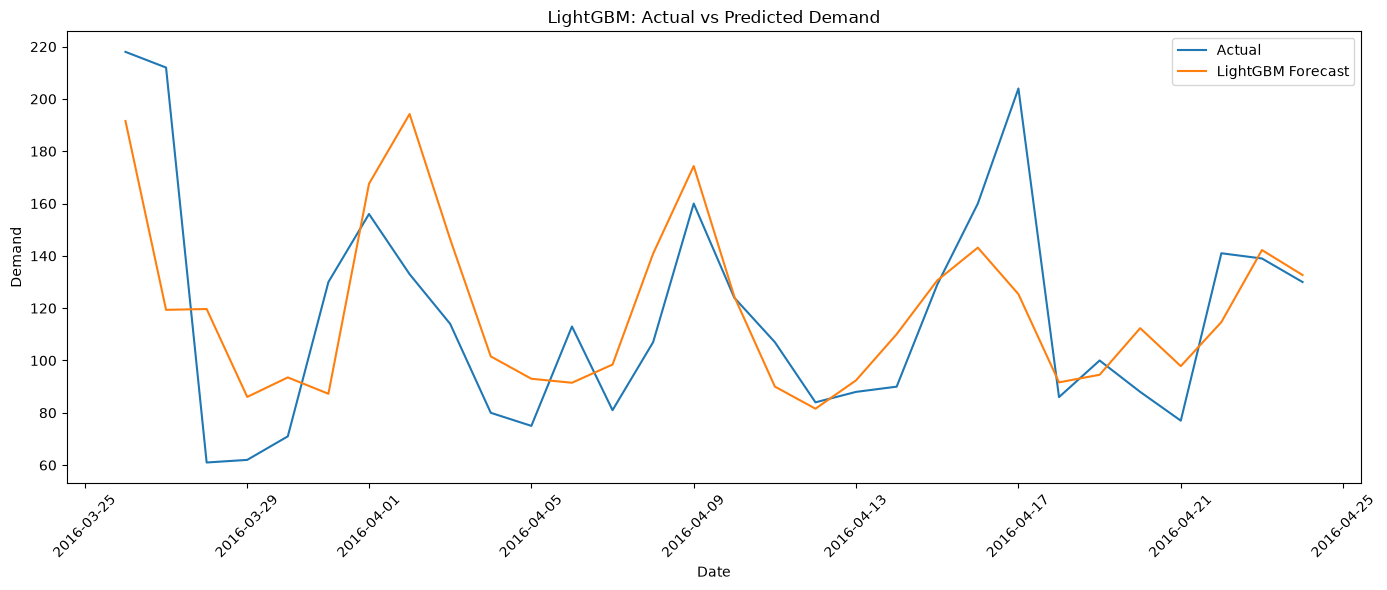

In [34]:
lgb_results = pd.DataFrame({
    "date": test_lgb["date"].values,
    "actual": y_test.values,
    "predicted": lgb_predictions
})

plt.figure(figsize=(14, 6))

plt.plot(
    lgb_results["date"],
    lgb_results["actual"],
    label="Actual"
)

plt.plot(
    lgb_results["date"],
    lgb_results["predicted"],
    label="LightGBM Forecast"
)

plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("LightGBM: Actual vs Predicted Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
importance = pd.DataFrame({
    "feature": features,
    "importance": lgb_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(importance)

,feature,importance
10,lag_1,2259
14,rolling_mean_7,1668
12,lag_14,1601
13,lag_28,1543
11,lag_7,1417
15,rolling_mean_14,1408
2,week_of_year,1164
16,rolling_mean_28,1149
1,day_of_month,1093
0,day_of_week,712


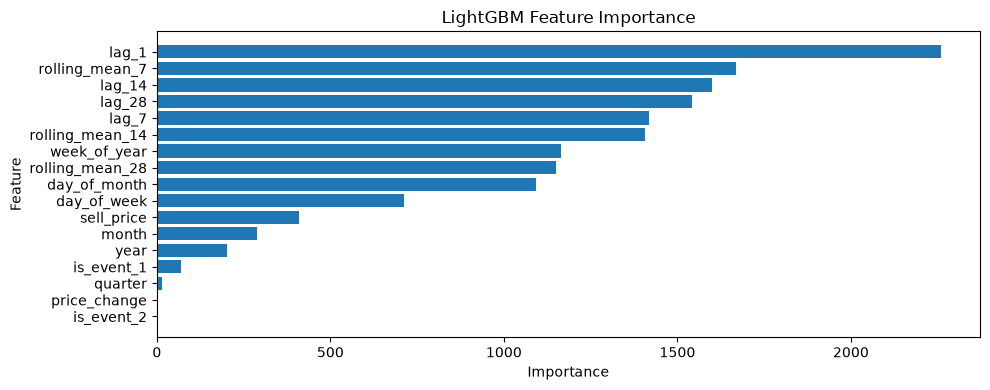

In [39]:
plt.figure(figsize=(10, 4))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [40]:
# Save LightGBM Forecast Results

lgb_results = pd.DataFrame({
    "item_id": product_id,
    "store_id": store_id,
    "date": test_lgb["date"].values,
    "actual": y_test.values,
    "predicted": lgb_predictions
})

lgb_results.to_csv(
    "../DATA/PROCESSED/lightgbm_forecast_FOODS_3_090_CA_3.csv",
    index=False
)

lgb_results.head()

,item_id,store_id,date,actual,predicted
0,FOODS_3_090,CA_3,2016-03-26,218,191.569675
1,FOODS_3_090,CA_3,2016-03-27,212,119.366081
2,FOODS_3_090,CA_3,2016-03-28,61,119.685597
3,FOODS_3_090,CA_3,2016-03-29,62,86.073759
4,FOODS_3_090,CA_3,2016-03-30,71,93.531201


In [43]:
# Model Comparison

model_comparison = pd.DataFrame({
    "Model": ["Prophet", "LightGBM"],
    "MAE": [47.06, 24.30],
    "RMSE": [56.87, 32.89],
    "WMAPE (%)": [40.11, 20.71]
})

model_comparison

,Model,MAE,RMSE,WMAPE (%)
0,Prophet,47.06,56.87,40.11
1,LightGBM,24.30,32.89,20.71


In [44]:
model_comparison.to_csv(
    "../DATA/PROCESSED/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!
